# Fine-tune a held-out (leave-one-out) task by learning ONLY its `p_vector` row

The `LeaveOneOutData84` checkpoints were each trained on the foundation battery with **one real task left out** (`metadata['left_out_task']`). The shared projections (`p2A/p2W/p2h/p2C/p2D`) and the trained `p_vector` rows are frozen.

For the held-out task we:
1. append **one new `p_vector` row**, initialized by **copying an existing trained task that shares the same output type** (`accuracy_type` in `foundation_tasks.TAGS`): `angular`, `binary`, `scalar`, `copytask`, `flipflop`, `argmax`, `vector`;
2. **freeze every weight** in the model, unfreeze only `p_vector`, and mask the gradient so **only the new row** moves;
3. train on **200 trials** of the held-out task, evaluate on **50 held-out test trials**.

Because only the new row is updated (old rows masked, all shared params frozen) the 99 pretrained tasks are bit-for-bit unchanged, so there is no forgetting to check.

This asks: *are the shared dynamical primitives general enough that a task never seen in training can be solved just by finding the right point in `p_vector` space?*

In [ ]:
import copy
import json
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# repo root = two levels up from foundation model/notebooks/
ROOT = Path.cwd()
while not (ROOT / "foundation_tasks").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("repo root:", ROOT)

from tasks.dataset import HierarchicalTasksDataset, collate_fn
from hierachical_model_task.model import HierarchicalPLRNN
from hierachical_model_task.utils import HiearchicalModelConfig
from hierachical_model_task.rnn_model import compute_accuracies, normalized_mse_loss
import foundation_tasks as ft

In [ ]:
# ----------------------------- configuration -----------------------------
LOO_DIR = ROOT / "data" / "LeaveOneOutData84"

# Which leave-one-out checkpoint to fine-tune. Either give the folder name, or
# leave CKPT_NAME = None and set LOO_INDEX to pick loo_<index>_*.
CKPT_NAME = None
LOO_INDEX = 0            # loo_0 -> held out 'NoiseCleaner'

# fine-tuning protocol
SAMPLE_SIZE   = 200      # training trials of the held-out task
N_TEST_TRIALS = 50       # test trials of the held-out task
NUM_EPOCHS    = 500
PATIENCE      = 200      # early-stop after this many epochs w/o test-acc gain (0 = off)
LR            = 1e-2
BATCH_SIZE    = 64
FINETUNE_SEED = 42
EVAL_EVERY    = 1
USE_GPU       = False

# p_vector init for the new row:
#   'auto'   -> copy a trained task with the same output type (accuracy_type)
#   'random' -> torch.empty(1, dp).uniform_(-1, 1)
#   '<TaskName>' -> copy that specific trained task's row
INIT_SOURCE = "auto"

DEVICE = "cuda" if (USE_GPU and torch.cuda.is_available()) else "cpu"

if CKPT_NAME is not None:
    ckpt_dir = LOO_DIR / CKPT_NAME
else:
    matches = sorted(LOO_DIR.glob(f"loo_{LOO_INDEX}_*"))
    assert matches, f"no loo_{LOO_INDEX}_* under {LOO_DIR}"
    ckpt_dir = matches[0]
assert (ckpt_dir / "model.pt").exists(), f"missing model.pt in {ckpt_dir}"
print("checkpoint:", ckpt_dir.name)
print("device:", DEVICE)

In [ ]:
# ----------------- load checkpoint + resolve task / init source -----------------
state = torch.load(ckpt_dir / "model.pt", map_location="cpu")
meta = json.loads((ckpt_dir / "metadata.json").read_text())

trained_names = meta["task_names"]          # the tasks this checkpoint WAS trained on
held_out_name = meta["left_out_task"]       # the task it was NOT trained on
print(f"held-out task: {held_out_name}   |   trained on {len(trained_names)} tasks")

# every checkpoint task must still exist in the current battery (row<->task alignment)
missing = [n for n in trained_names if n not in ft.FOUNDATION_TASKS_MAP]
assert not missing, f"checkpoint tasks missing from current battery: {missing[:5]}"
assert held_out_name in ft.FOUNDATION_TASKS_MAP, f"unknown held-out task {held_out_name}"
assert held_out_name not in trained_names, "held-out task is in the trained set?!"

# assemble tasks in the SAME order as the checkpoint's p_vector rows, new task last
all_tasks = [ft.FOUNDATION_TASKS_MAP[n] for n in trained_names] + [ft.FOUNDATION_TASKS_MAP[held_out_name]]
all_names = trained_names + [held_out_name]
new_idx = len(all_tasks) - 1

# --- choose the init source by matching output type (accuracy_type) ---
held_type = ft.TAGS[held_out_name]["accuracy_type"]
same_type = [n for n in trained_names if ft.TAGS[n]["accuracy_type"] == held_type]
print(f"output type of {held_out_name}: '{held_type}'  ->  {len(same_type)} trained tasks share it")
print("   candidates:", same_type[:12], ("..." if len(same_type) > 12 else ""))

if INIT_SOURCE == "auto":
    assert same_type, f"no trained task shares output type '{held_type}'; set INIT_SOURCE manually"
    init_source = same_type[0]
else:
    init_source = INIT_SOURCE
    if init_source not in ("random",) and init_source not in trained_names:
        raise ValueError(f"INIT_SOURCE '{init_source}' is not 'random'/'auto' or a trained task")
print("init source for the new p_vector row:", init_source)

In [ ]:
# ------------------- print every task (row order = p_vector row order) -------------------
print(f"{len(all_names)} tasks  (rows 0..{len(trained_names) - 1} trained, row {new_idx} = held-out '{held_out_name}')\n")
for i, name in enumerate(all_names):
    otype = ft.TAGS[name]["accuracy_type"]
    tag = ""
    if i == new_idx:
        tag = "  <== HELD OUT (new p_vector row)"
    elif name == init_source:
        tag = "  <== init source"
    print(f"  [{i:3d}] {name:<26} {otype:<9}{tag}")

In [ ]:
# --------------------- build the model with one appended row ---------------------
# config identical to how the checkpoint was trained
args = HiearchicalModelConfig(tasks=all_tasks)
args.num_individual_params = meta["num_individual_params"]
args.nonlinear_units       = meta["nonlinear_units"]
args.hidden_size           = meta["hidden_size"]
args.a_clamp               = meta.get("a_clamp", 0.0)
args.hierarchisation       = "all"
args.device                = DEVICE

old_p = state["p_vector"]
old_n, dp = old_p.shape
assert old_n == len(trained_names), f"p_vector rows ({old_n}) != trained tasks ({len(trained_names)})"

# initialize the new task's p_vector row
torch.manual_seed(FINETUNE_SEED); np.random.seed(FINETUNE_SEED)
if init_source == "random":
    new_row = torch.empty(1, dp).uniform_(-1, 1)
else:
    src = trained_names.index(init_source)
    new_row = old_p[src:src + 1].clone()

state["p_vector"] = torch.cat([old_p, new_row], dim=0)
if "noise_cov" in state:                       # keep the per-task noise buffer aligned
    old_noise = state["noise_cov"]
    state["noise_cov"] = torch.cat([old_noise, torch.zeros(1, *old_noise.shape[1:])], dim=0)

model = HierarchicalPLRNN(args, HierarchicalTasksDataset)
model.load_state_dict(state)
model.to(DEVICE)

# freeze everything, unfreeze p_vector, mask all but the new (last) row
for p in model.parameters():
    p.requires_grad = False
model.p_vector.requires_grad = True

def _mask_old(grad, n_old=old_n):
    grad[:n_old] = 0                            # only the new row keeps its gradient
    return grad
model.p_vector.register_hook(_mask_old)

optimizer = torch.optim.Adam([model.p_vector], lr=LR)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable params: {n_trainable} (should be one p_vector row = {dp})")

In [ ]:
# ------------------------------- data (fixed trials) -------------------------------
torch.manual_seed(FINETUNE_SEED); np.random.seed(FINETUNE_SEED)
train_ds = HierarchicalTasksDataset(
    all_tasks, n_trials=SAMPLE_SIZE, task_indices=[new_idx] * SAMPLE_SIZE, fixed=True
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

test_ds = HierarchicalTasksDataset(
    all_tasks, n_trials=N_TEST_TRIALS, task_indices=[new_idx] * N_TEST_TRIALS, fixed=True
)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

task_loss_channels = {
    i: t.loss_channels for i, t in enumerate(all_tasks)
    if getattr(t, "loss_channels", None) is not None
}
print(f"train trials: {len(train_ds)}  |  test trials: {len(test_ds)}")

In [ ]:
# ---------------------------------- helpers ----------------------------------
def _test_loss(model, loader):
    model.eval()
    tot, nb = 0.0, 0
    with torch.no_grad():
        for inputs, targets, masks, task_ids in loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            masks, task_ids = masks.to(DEVICE), task_ids.to(DEVICE)
            outputs = model(inputs, task_ids)
            me = masks.unsqueeze(-1).expand_as(outputs)
            mo = outputs * me
            if targets.dim() == 2:
                mt = targets.unsqueeze(1).expand(-1, outputs.shape[1], -1) * me
            else:
                mt = targets * me
            tot += normalized_mse_loss(mo, mt, masks, task_ids, task_loss_channels).item()
            nb += 1
    return tot / max(nb, 1)

In [ ]:
# --------------------------------- train loop ---------------------------------
p_before = model.p_vector.detach().clone()          # for the frozen-rows sanity check

torch.manual_seed(FINETUNE_SEED); np.random.seed(FINETUNE_SEED)
hist = {"epoch": [], "train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}
best_acc, best_epoch, best_state = -1.0, None, None
stopped_epoch = NUM_EPOCHS                          # actual epochs run (patience / 100% may cut short)

for epoch in range(NUM_EPOCHS):
    model.train()
    ep_loss = 0.0
    for inputs, targets, masks, task_ids in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        masks, task_ids = masks.to(DEVICE), task_ids.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs, task_ids)
        me = masks.unsqueeze(-1).expand_as(outputs)
        mo = outputs * me
        if targets.dim() == 2:
            mt = targets.unsqueeze(1).expand(-1, outputs.shape[1], -1) * me
        else:
            mt = targets * me
        loss = normalized_mse_loss(mo, mt, masks, task_ids, task_loss_channels)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()
    train_loss = ep_loss / len(train_loader)

    if epoch == 0 or (epoch + 1) % EVAL_EVERY == 0 or epoch == NUM_EPOCHS - 1:
        tr_acc = compute_accuracies(model, train_loader, DEVICE, len(all_tasks), tasks=all_tasks).get(new_idx, 0.0)
        te_acc = compute_accuracies(model, test_loader,  DEVICE, len(all_tasks), tasks=all_tasks).get(new_idx, 0.0)
        te_loss = _test_loss(model, test_loader)
        hist["epoch"].append(epoch)
        hist["train_loss"].append(train_loss)
        hist["test_loss"].append(te_loss)
        hist["train_acc"].append(tr_acc)
        hist["test_acc"].append(te_acc)
        if te_acc > best_acc:
            best_acc, best_epoch = te_acc, epoch + 1
            best_state = copy.deepcopy(model.state_dict())
        if (epoch + 1) % 25 == 0 or epoch == 0:
            print(f"epoch {epoch + 1:4d} | train_loss {train_loss:.4f} | test_loss {te_loss:.4f} "
                  f"| train_acc {tr_acc:.3f} | test_acc {te_acc:.3f} | best {best_acc:.3f}")
        # early stop: perfect test accuracy, or no improvement for PATIENCE epochs
        if te_acc >= 1.0:
            stopped_epoch = epoch + 1
            print(f"early stop at epoch {stopped_epoch} (100% test accuracy)")
            break
        if PATIENCE and best_epoch is not None and (epoch + 1) - best_epoch >= PATIENCE:
            stopped_epoch = epoch + 1
            print(f"early stop at epoch {stopped_epoch} (no improvement for {PATIENCE} epochs; best @ {best_epoch})")
            break

# --- sanity check: only the new row moved ---
p_after = model.p_vector.detach()
moved_old = (p_after[:old_n] - p_before[:old_n]).abs().max().item()
moved_new = (p_after[old_n:] - p_before[old_n:]).abs().max().item()
print(f"\nmax |dp| old rows = {moved_old:.2e} (should be ~0) | new row = {moved_new:.2e}")
assert moved_old < 1e-6, "old p_vector rows changed -- gradient mask failed!"

if best_state is not None:
    model.load_state_dict(best_state)
print(f"\n{held_out_name} <- {init_source}: best test acc {best_acc:.1%} @ epoch {best_epoch}")

In [ ]:
# ------------------------------- learning curves -------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist["epoch"], hist["train_loss"], label="train")
ax[0].plot(hist["epoch"], hist["test_loss"], label="test")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("normalized MSE"); ax[0].set_title("loss"); ax[0].legend()
ax[1].plot(hist["epoch"], hist["train_acc"], label="train")
ax[1].plot(hist["epoch"], hist["test_acc"], label="test")
ax[1].axhline(best_acc, ls="--", c="gray", lw=1, label=f"best {best_acc:.2f}")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy"); ax[1].set_ylim(-0.02, 1.02)
ax[1].set_title(f"{held_out_name}  (init from {init_source})"); ax[1].legend()
fig.tight_layout(); plt.show()

In [ ]:
# ----------------------------------- save -----------------------------------
# per-epoch history columns match the script's history.csv so the two are
# consistent (identifying columns first, so histories can be stacked).
import pandas as pd
HISTORY_FIELDS = ["loo_index", "new_task", "output_type", "init_source",
                  "epoch", "train_loss", "test_loss", "train_acc", "test_acc"]

out = ckpt_dir / f"finetune_{held_out_name}_init{init_source}"
out.mkdir(parents=True, exist_ok=True)
torch.save(best_state, out / "model.pt")
np.savez(out / "history.npz", **{k: np.array(v) for k, v in hist.items()})

loo_index = meta.get("left_out_index")
hist_df = pd.DataFrame({
    "loo_index": loo_index, "new_task": held_out_name, "output_type": held_type,
    "init_source": init_source, "epoch": hist["epoch"], "train_loss": hist["train_loss"],
    "test_loss": hist["test_loss"], "train_acc": hist["train_acc"], "test_acc": hist["test_acc"],
})[HISTORY_FIELDS]
hist_df.to_csv(out / "history.csv", index=False)

torch.save({"p_init_row": new_row.cpu(), "init_source": init_source, "new_task_idx": new_idx,
            "final_p_row": p_after[old_n:].cpu(),
            "best_p_row": (best_state["p_vector"][old_n:].cpu() if best_state is not None else p_after[old_n:].cpu())},
           out / "p_vector.pt")
with open(out / "results.json", "w") as f:
    json.dump({
        "new_task": held_out_name, "init_source": init_source, "output_type": held_type,
        "checkpoint": str(ckpt_dir),
        "sample_size": SAMPLE_SIZE, "n_test_trials": N_TEST_TRIALS,
        "num_epochs": NUM_EPOCHS, "patience": PATIENCE, "stopped_epoch": stopped_epoch,
        "lr": LR, "batch_size": BATCH_SIZE, "finetune_seed": FINETUNE_SEED,
        "best_test_acc": best_acc, "best_epoch": best_epoch,
        "final_test_acc": hist["test_acc"][-1] if hist["test_acc"] else 0.0,
        "final_train_acc": hist["train_acc"][-1] if hist["train_acc"] else 0.0,
        "moved_old_rows_max": moved_old, "moved_new_row_max": moved_new,
    }, f, indent=2)
print("saved ->", out)

## Batch: fine-tune every leave-one-out checkpoint

Runs the same protocol across all `loo_*` folders. Writes, into `LOO_DIR`:
- `finetune_loo_summary.csv` — one row per held-out task (best/final acc),
- `finetune_loo_history.csv` — **every task's full per-epoch curve, stacked** (same columns as each run's `history.csv`, matching the `finetune_leaveoneout.py` script).

Set `LIMIT` to a small number for a quick smoke test.

In [ ]:
import pandas as pd

# per-epoch history columns (shared with each run's history.csv and the script)
HISTORY_FIELDS = ["loo_index", "new_task", "output_type", "init_source",
                  "epoch", "train_loss", "test_loss", "train_acc", "test_acc"]


def finetune_loo(ckpt_dir, sample_size=200, n_test_trials=50, num_epochs=500,
                 lr=1e-2, batch_size=64, seed=42, init_source="auto",
                 eval_every=1, patience=200, device=DEVICE, save=True):
    state = torch.load(ckpt_dir / "model.pt", map_location="cpu")
    meta = json.loads((ckpt_dir / "metadata.json").read_text())
    trained_names, held = meta["task_names"], meta["left_out_task"]
    assert held in ft.FOUNDATION_TASKS_MAP and held not in trained_names
    all_tasks = [ft.FOUNDATION_TASKS_MAP[n] for n in trained_names] + [ft.FOUNDATION_TASKS_MAP[held]]
    new_idx = len(all_tasks) - 1

    held_type = ft.TAGS[held]["accuracy_type"]
    if init_source == "auto":
        cands = [n for n in trained_names if ft.TAGS[n]["accuracy_type"] == held_type]
        if not cands:
            raise ValueError(f"no trained task shares output type '{held_type}' with {held}")
        src_name = cands[0]
    else:
        src_name = init_source

    a = HiearchicalModelConfig(tasks=all_tasks)
    a.num_individual_params = meta["num_individual_params"]
    a.nonlinear_units = meta["nonlinear_units"]; a.hidden_size = meta["hidden_size"]
    a.a_clamp = meta.get("a_clamp", 0.0); a.hierarchisation = "all"; a.device = device

    old_p = state["p_vector"]; old_n, dp = old_p.shape
    torch.manual_seed(seed); np.random.seed(seed)
    new_row = (torch.empty(1, dp).uniform_(-1, 1) if src_name == "random"
               else old_p[trained_names.index(src_name):trained_names.index(src_name) + 1].clone())
    state["p_vector"] = torch.cat([old_p, new_row], dim=0)
    if "noise_cov" in state:
        state["noise_cov"] = torch.cat([state["noise_cov"], torch.zeros(1, *state["noise_cov"].shape[1:])], dim=0)

    m = HierarchicalPLRNN(a, HierarchicalTasksDataset); m.load_state_dict(state); m.to(device)
    for p in m.parameters():
        p.requires_grad = False
    m.p_vector.requires_grad = True
    m.p_vector.register_hook(lambda g, n=old_n: (g.__setitem__(slice(0, n), 0), g)[1])
    opt = torch.optim.Adam([m.p_vector], lr=lr)

    torch.manual_seed(seed); np.random.seed(seed)
    tr = DataLoader(HierarchicalTasksDataset(all_tasks, n_trials=sample_size,
                    task_indices=[new_idx] * sample_size, fixed=True),
                    batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    te = DataLoader(HierarchicalTasksDataset(all_tasks, n_trials=n_test_trials,
                    task_indices=[new_idx] * n_test_trials, fixed=True),
                    batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    tlc = {i: t.loss_channels for i, t in enumerate(all_tasks) if getattr(t, "loss_channels", None) is not None}

    def _tloss(loader):
        m.eval(); tot = nb = 0
        with torch.no_grad():
            for inputs, targets, masks, task_ids in loader:
                inputs, targets = inputs.to(device), targets.to(device)
                masks, task_ids = masks.to(device), task_ids.to(device)
                out = m(inputs, task_ids); me = masks.unsqueeze(-1).expand_as(out); mo = out * me
                mt = (targets.unsqueeze(1).expand(-1, out.shape[1], -1) * me) if targets.dim() == 2 else targets * me
                tot += normalized_mse_loss(mo, mt, masks, task_ids, tlc).item(); nb += 1
        return tot / max(nb, 1)

    loo_index = meta.get("left_out_index")
    history_rows = []
    best_acc, best_epoch, best_state = -1.0, None, None
    for epoch in range(num_epochs):
        m.train(); ep_loss = 0.0
        for inputs, targets, masks, task_ids in tr:
            inputs, targets = inputs.to(device), targets.to(device)
            masks, task_ids = masks.to(device), task_ids.to(device)
            opt.zero_grad()
            out = m(inputs, task_ids); me = masks.unsqueeze(-1).expand_as(out); mo = out * me
            mt = (targets.unsqueeze(1).expand(-1, out.shape[1], -1) * me) if targets.dim() == 2 else targets * me
            loss = normalized_mse_loss(mo, mt, masks, task_ids, tlc)
            loss.backward(); opt.step(); ep_loss += loss.item()
        train_loss = ep_loss / len(tr)
        if epoch == 0 or (epoch + 1) % eval_every == 0 or epoch == num_epochs - 1:
            tr_acc = compute_accuracies(m, tr, device, len(all_tasks), tasks=all_tasks).get(new_idx, 0.0)
            te_acc = compute_accuracies(m, te, device, len(all_tasks), tasks=all_tasks).get(new_idx, 0.0)
            te_loss = _tloss(te)
            history_rows.append({"loo_index": loo_index, "new_task": held,
                                 "output_type": held_type, "init_source": src_name,
                                 "epoch": epoch, "train_loss": train_loss, "test_loss": te_loss,
                                 "train_acc": tr_acc, "test_acc": te_acc})
            if te_acc > best_acc:
                best_acc, best_epoch = te_acc, epoch + 1
                best_state = copy.deepcopy(m.state_dict())
            if te_acc >= 1.0:
                break
            if patience and best_epoch is not None and (epoch + 1) - best_epoch >= patience:
                break

    if save and best_state is not None:
        o = ckpt_dir / f"finetune_{held}_init{src_name}"; o.mkdir(parents=True, exist_ok=True)
        torch.save(best_state, o / "model.pt")
        pd.DataFrame(history_rows)[HISTORY_FIELDS].to_csv(o / "history.csv", index=False)
        json.dump({"new_task": held, "init_source": src_name, "output_type": held_type,
                   "best_test_acc": best_acc, "best_epoch": best_epoch}, open(o / "results.json", "w"), indent=2)
    return {"loo_index": loo_index, "task": held, "output_type": held_type,
            "init_source": src_name, "best_test_acc": best_acc, "best_epoch": best_epoch,
            "history_rows": history_rows}

In [ ]:
LIMIT = None    # e.g. 3 for a quick smoke test; None = all 84 checkpoints
folders = sorted(LOO_DIR.glob("loo_*"), key=lambda p: int(p.name.split("_")[1]))
if LIMIT is not None:
    folders = folders[:LIMIT]

rows, all_history, skipped = [], [], []
for i, d in enumerate(folders):
    try:
        r = finetune_loo(d, sample_size=SAMPLE_SIZE, n_test_trials=N_TEST_TRIALS,
                         num_epochs=NUM_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
                         seed=FINETUNE_SEED, init_source=INIT_SOURCE,
                         eval_every=EVAL_EVERY, patience=PATIENCE)
    except ValueError as e:
        skipped.append((d.name, str(e)))
        print(f"[{i + 1}/{len(folders)}] {d.name}  SKIP: {e}")
        continue
    all_history.extend(r.pop("history_rows"))
    rows.append(r)
    print(f"[{i + 1}/{len(folders)}] {r['task']:<24} ({r['output_type']:<8}) "
          f"<- {r['init_source']:<16} best_test_acc {r['best_test_acc']:.1%}")

# summary: one row per held-out task
df = pd.DataFrame(rows).sort_values("best_test_acc", ascending=False).reset_index(drop=True)
df.to_csv(LOO_DIR / "finetune_loo_summary.csv", index=False)

# stacked per-epoch history: every task's full curve, one after the other
hist_df = pd.DataFrame(all_history)[HISTORY_FIELDS]
hist_df.to_csv(LOO_DIR / "finetune_loo_history.csv", index=False)

print(f"\nmean best_test_acc over {len(df)} held-out tasks: {df['best_test_acc'].mean():.1%}")
if skipped:
    print(f"skipped {len(skipped)} (no same-type init source): {[s[0] for s in skipped]}")
print("summary ->", LOO_DIR / "finetune_loo_summary.csv")
print("stacked per-epoch history ->", LOO_DIR / "finetune_loo_history.csv")
df

## Results

Loads `finetune_loo_summary.csv` (written by the sweep above or by `finetune_leaveoneout.py --all`) and reports, per held-out task, the best test accuracy reached by training **only its new `p_vector` row**. Bars are colored by output type; the dashed line is the mean.

83 fine-tuned held-out tasks | mean best_test_acc = 81.7% | 33/83 reached 100%

mean best_test_acc by output type:
              n  mean
output_type          
binary       46 88.1%
angular      16 87.1%
scalar        6 82.7%
argmax        2 66.0%
flipflop      2 62.2%
copytask     11 53.0%


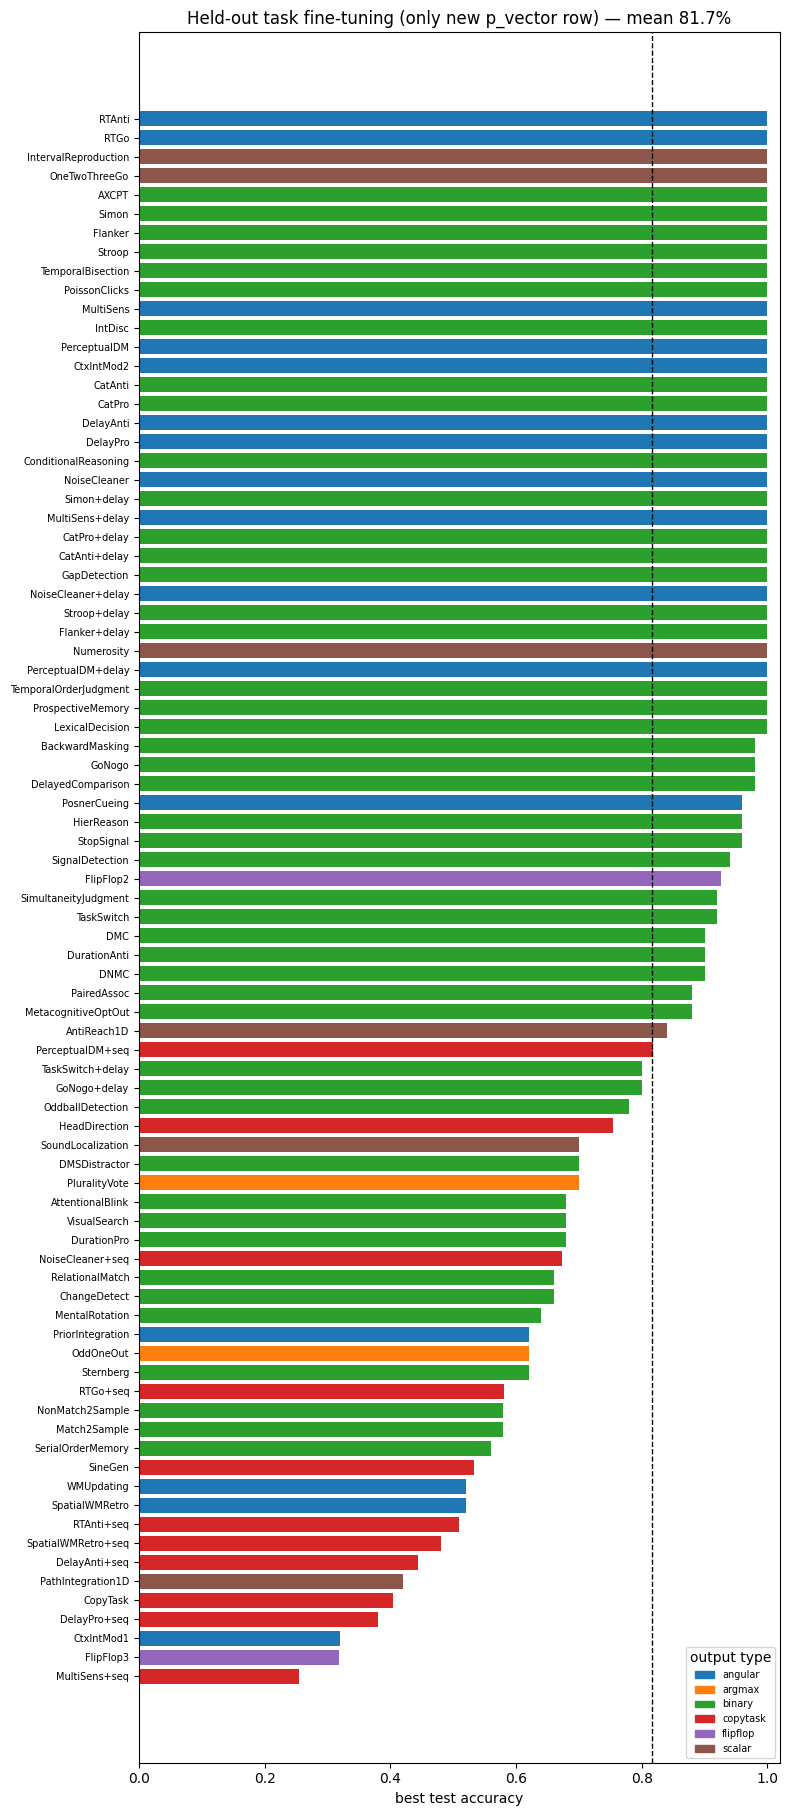

,loo_index,new_task,output_type,init_source,best_test_acc,best_epoch,final_test_acc
0,0,NoiseCleaner,angular,DelayPro,1.000000,1,1.000000
1,1,DelayPro,angular,NoiseCleaner,1.000000,38,1.000000
2,2,DelayAnti,angular,NoiseCleaner,1.000000,237,1.000000
3,3,CatPro,binary,CatAnti,1.000000,28,1.000000
4,4,CatAnti,binary,CatPro,1.000000,3,1.000000
...,...,...,...,...,...,...,...
78,9,CopyTask,copytask,SineGen,0.405000,101,0.397500
79,76,DelayPro+seq,copytask,CopyTask,0.380706,464,0.353230
80,7,CtxIntMod1,angular,NoiseCleaner,0.320000,135,0.240000
81,18,FlipFlop3,flipflop,FlipFlop2,0.317599,368,0.308741


In [21]:
# ================================ results ================================
import pandas as pd
from matplotlib.patches import Patch

# resolve LOO_DIR even if only this cell is run
try:
    LOO_DIR
except NameError:
    _r = Path.cwd()
    while not (_r / "foundation_tasks").exists() and _r != _r.parent:
        _r = _r.parent
    LOO_DIR = _r / "data" / "LeaveOneOutData84"

summary_csv = LOO_DIR / "finetune_loo_summary.csv"
if summary_csv.exists():
    res = pd.read_csv(summary_csv)
else:  # fall back to each checkpoint's results.json
    recs = [json.loads(p.read_text())
            for p in sorted(LOO_DIR.glob("loo_*/finetune_*_init*/results.json"))]
    res = pd.DataFrame(recs)

task_col = "new_task" if "new_task" in res.columns else "task"
res = res.sort_values("best_test_acc", ascending=False).reset_index(drop=True)
mean_acc = res["best_test_acc"].mean()
n_perfect = int((res["best_test_acc"] >= 1.0).sum())
print(f"{len(res)} fine-tuned held-out tasks | mean best_test_acc = {mean_acc:.1%} | "
      f"{n_perfect}/{len(res)} reached 100%\n")

print("mean best_test_acc by output type:")
by_type = (res.groupby("output_type")["best_test_acc"]
             .agg(n="count", mean="mean").sort_values("mean", ascending=False))
print(by_type.to_string(formatters={"mean": lambda x: f"{x:.1%}"}))

# --- per-task bar chart, colored by output type ---
types = sorted(res["output_type"].unique())
cmap = plt.get_cmap("tab10")
color = {t: cmap(i % 10) for i, t in enumerate(types)}
r2 = res.sort_values("best_test_acc")

fig, ax = plt.subplots(figsize=(8, max(4, 0.22 * len(r2))))
ax.barh(range(len(r2)), r2["best_test_acc"], color=[color[t] for t in r2["output_type"]])
ax.set_yticks(range(len(r2))); ax.set_yticklabels(r2[task_col], fontsize=7)
ax.set_xlim(0, 1.02); ax.set_xlabel("best test accuracy")
ax.axvline(mean_acc, ls="--", c="k", lw=1)
ax.set_title(f"Held-out task fine-tuning (only new p_vector row) — mean {mean_acc:.1%}")
ax.legend(handles=[Patch(color=color[t], label=t) for t in types],
          title="output type", fontsize=7, loc="lower right")
fig.tight_layout(); plt.show()

res  # full sorted table

83 fine-tuned held-out tasks | mean best_test_acc = 81.7% | 33/83 reached 100%

reference (joint N4P8): 3 seeds -> [2, 3, 4]

mean best_test_acc by output type (finetune vs joint reference):
              n finetune joint_ref
output_type                       
binary       46    88.1%     92.4%
angular      16    87.1%     93.9%
scalar        6    82.7%     88.2%
argmax        2    66.0%     99.3%
flipflop      2    62.2%     91.0%
copytask     11    53.0%     94.0%

overall: finetune 81.7%  vs  joint-ref 92.7%  (mean gap -11.0%)


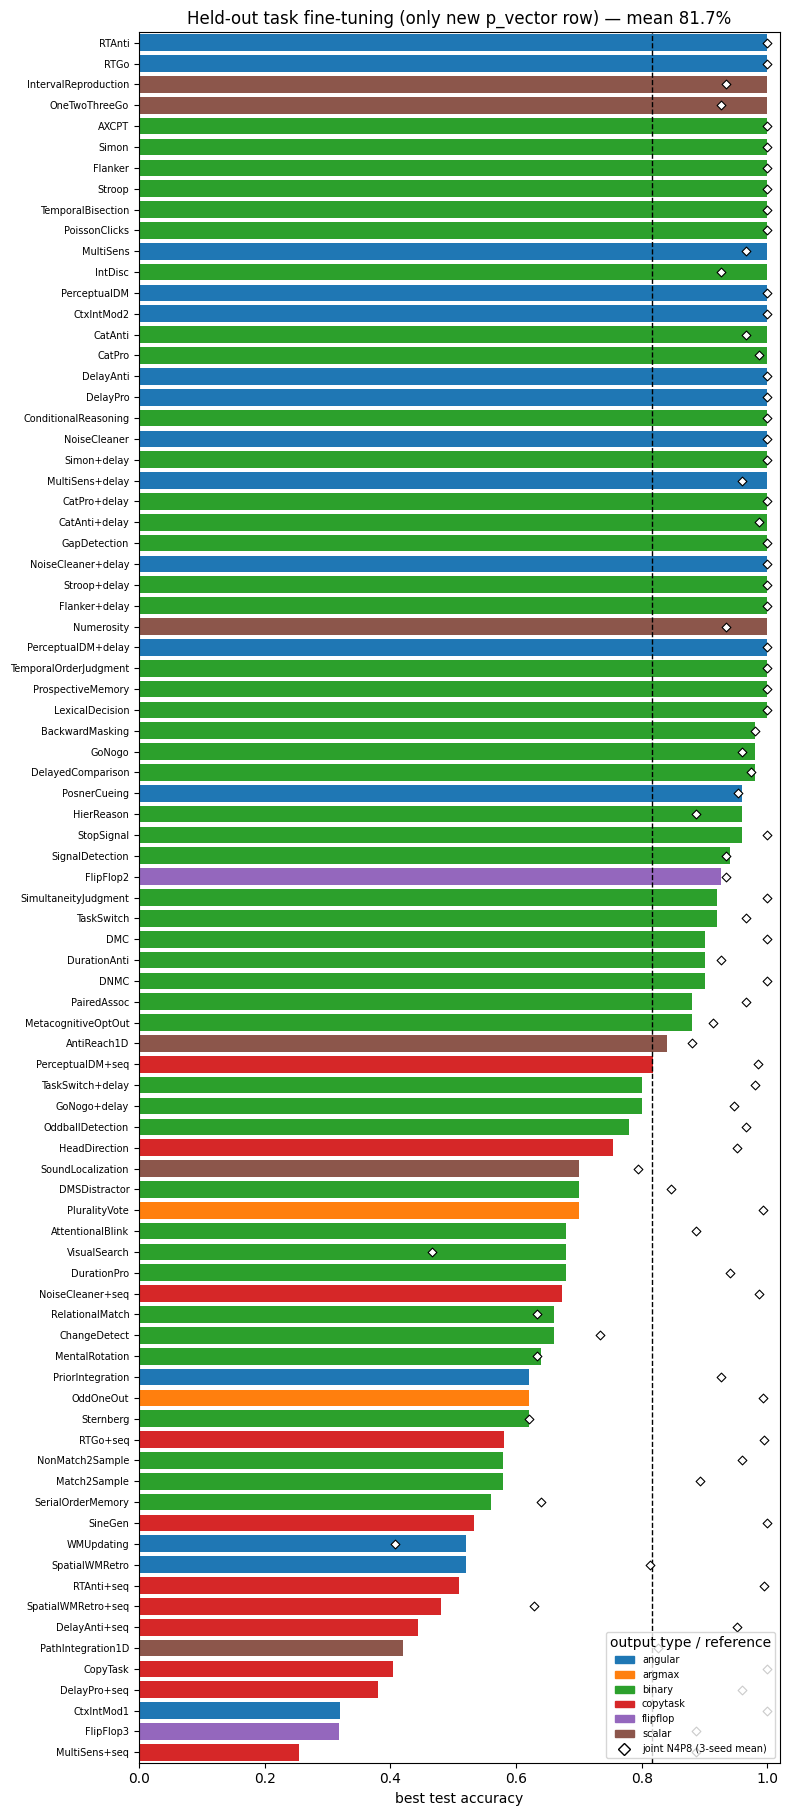

,loo_index,new_task,output_type,init_source,best_test_acc,best_epoch,final_test_acc,joint_ref_acc,gap
0,0,NoiseCleaner,angular,DelayPro,1.000000,1,1.000000,1.000000,0.000000
1,1,DelayPro,angular,NoiseCleaner,1.000000,38,1.000000,1.000000,0.000000
2,2,DelayAnti,angular,NoiseCleaner,1.000000,237,1.000000,1.000000,0.000000
3,3,CatPro,binary,CatAnti,1.000000,28,1.000000,0.986667,0.013333
4,4,CatAnti,binary,CatPro,1.000000,3,1.000000,0.966667,0.033333
...,...,...,...,...,...,...,...,...,...
78,9,CopyTask,copytask,SineGen,0.405000,101,0.397500,1.000000,-0.595000
79,76,DelayPro+seq,copytask,CopyTask,0.380706,464,0.353230,0.958757,-0.578050
80,7,CtxIntMod1,angular,NoiseCleaner,0.320000,135,0.240000,1.000000,-0.680000
81,18,FlipFlop3,flipflop,FlipFlop2,0.317599,368,0.308741,0.885815,-0.568216


In [22]:
# ================================ results ================================
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# resolve LOO_DIR even if only this cell is run
try:
    LOO_DIR
    ROOT
except NameError:
    ROOT = Path.cwd()
    while not (ROOT / "foundation_tasks").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    LOO_DIR = ROOT / "data" / "LeaveOneOutData84"

summary_csv = LOO_DIR / "finetune_loo_summary.csv"
if summary_csv.exists():
    res = pd.read_csv(summary_csv)
else:  # fall back to each checkpoint's results.json
    recs = [json.loads(p.read_text())
            for p in sorted(LOO_DIR.glob("loo_*/finetune_*_init*/results.json"))]
    res = pd.DataFrame(recs)

task_col = "new_task" if "new_task" in res.columns else "task"
res = res.sort_values("best_test_acc", ascending=False).reset_index(drop=True)
mean_acc = res["best_test_acc"].mean()
n_perfect = int((res["best_test_acc"] >= 1.0).sum())
print(f"{len(res)} fine-tuned held-out tasks | mean best_test_acc = {mean_acc:.1%} | "
      f"{n_perfect}/{len(res)} reached 100%\n")

# --- reference: joint N=4 P=8 training, per-task best acc averaged over 3 seeds ---
REF_DIR = ROOT / "data" / "M64_lr5e4_NPsweep"
ref_meta = [json.loads((d / "metadata.json").read_text())
            for d in sorted(REF_DIR.glob("foundation_joint_M64_N4_P8_*seed*"))]
print(f"reference (joint N4P8): {len(ref_meta)} seeds "
      f"-> {[m['seed'] for m in ref_meta]}")
ref_per_seed = pd.DataFrame([m["best_test_accuracy_per_task"] for m in ref_meta])
ref_mean = ref_per_seed.mean(axis=0)          # task -> mean best acc across seeds
res["joint_ref_acc"] = res[task_col].map(ref_mean)
res["gap"] = res["best_test_acc"] - res["joint_ref_acc"]   # finetune - joint

print("\nmean best_test_acc by output type (finetune vs joint reference):")
by_type = (res.groupby("output_type")
             .agg(n=("best_test_acc", "count"),
                  finetune=("best_test_acc", "mean"),
                  joint_ref=("joint_ref_acc", "mean"))
             .sort_values("finetune", ascending=False))
print(by_type.to_string(formatters={"finetune": lambda x: f"{x:.1%}",
                                     "joint_ref": lambda x: f"{x:.1%}"}))
print(f"\noverall: finetune {mean_acc:.1%}  vs  joint-ref "
      f"{res['joint_ref_acc'].mean():.1%}  (mean gap {res['gap'].mean():+.1%})")

# --- per-task bar chart, colored by output type, with joint reference overlaid ---
types = sorted(res["output_type"].unique())
cmap = plt.get_cmap("tab10")
color = {t: cmap(i % 10) for i, t in enumerate(types)}
r2 = res.sort_values("best_test_acc")
y = range(len(r2))

fig, ax = plt.subplots(figsize=(8, max(4, 0.22 * len(r2))))
ax.barh(y, r2["best_test_acc"], color=[color[t] for t in r2["output_type"]])
# joint N4P8 3-seed-mean reference, one marker per task
ax.scatter(r2["joint_ref_acc"], y, marker="D", s=20, facecolor="white",
           edgecolor="black", linewidths=0.8, zorder=3)
ax.set_yticks(list(y)); ax.set_yticklabels(r2[task_col], fontsize=7)
ax.set_ylim(-0.5, len(r2) - 0.5)
ax.set_xlim(0, 1.02); ax.set_xlabel("best test accuracy")
ax.axvline(mean_acc, ls="--", c="k", lw=1)
ax.set_title(f"Held-out task fine-tuning (only new p_vector row) — mean {mean_acc:.1%}")

legend_handles = [Patch(color=color[t], label=t) for t in types]
legend_handles.append(Line2D([0], [0], marker="D", linestyle="none",
                             markerfacecolor="white", markeredgecolor="black",
                             label="joint N4P8 (3-seed mean)"))
ax.legend(handles=legend_handles, title="output type / reference",
          fontsize=7, loc="lower right")
fig.tight_layout(); plt.show()

res  # full sorted table (now includes joint_ref_acc and gap)
